# Nestlé (NESN) DCF Case Study

End-to-end valuation with automated data (yfinance).

## 1. Setup

In [2]:
import importlib.util

if importlib.util.find_spec("yfinance") is None:
    !pip install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


  Using cached yfinance-1.3.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached peewee-4.0.5-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-macosx_11_0_arm64.whl.metadata (18 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached websockets-16.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached yfinance-1.3.0-py2.py3-none-any.whl (133 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-macosx_11_0_arm64.whl (2.6 MB)
Using cached frozendict-2.4.7-py3-none-any.whl (16 kB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.0.5-py3-none-any.whl (144 kB)
Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universa

## 2. Fetch Data (NESN.SW)

In [3]:
ticker = yf.Ticker('NESN.SW')
info = ticker.info
financials = ticker.financials
cashflow = ticker.cashflow
balance = ticker.balance_sheet

info

{'address1': 'Avenue Nestlé 55',
 'city': 'Vevey',
 'zip': '1800',
 'country': 'Switzerland',
 'phone': '41 21 924 1111',
 'website': 'https://www.nestle.com',
 'industry': 'Packaged Foods',
 'industryKey': 'packaged-foods',
 'industryDisp': 'Packaged Foods',
 'sector': 'Consumer Defensive',
 'sectorKey': 'consumer-defensive',
 'sectorDisp': 'Consumer Defensive',
 'longBusinessSummary': 'Nestlé S.A., together with its subsidiaries, operates as a food and beverage company. It operates through Zone North America; Zone Europe; Zone Asia, Oceania and Africa; Zone Latin America; Zone Greater China; Nestlé Health Science; and Nespresso segments. It offers water under the Acqua Panna, Nestlé Pure Life, Perrier, S.Pellegrino, Sanpellegrino, and other local brands; and chocolate and confectionery products under the Aero, Baci Perugina, KitKat, Milkybar, Smarties, and other local brands; family nutrition products, including early childhood, kids and teenagers, and maternal and adult products; ce

## 3. Estimate Free Cash Flow (proxy)
Using operating cash flow - capex

In [5]:
try:
    ocf = cashflow.loc['Total Cash From Operating Activities'][0]
    capex = cashflow.loc['Capital Expenditures'][0]
    fcf0 = ocf + capex  # capex usually negative
except:
    fcf0 = 10000000000  # fallback approx

fcf0

10000000000

## 4. WACC Assumptions

In [6]:
rf = 0.015
beta = 0.65
mrp = 0.055
re = rf + beta * mrp
rd = 0.03
tax = 0.21
wacc = 0.85 * re + 0.15 * rd * (1 - tax)

wacc

0.046692500000000005

## 5. DCF Functions

In [7]:
def project_fcf(fcf0, growth, years):
    return [fcf0 * (1 + growth)**t for t in range(1, years+1)]

def terminal_value(fcf_last, g, r):
    return fcf_last * (1 + g) / (r - g)

def dcf(fcf0, growth, r, g_terminal, years):
    fcfs = project_fcf(fcf0, growth, years)
    discounted = [fcf / (1 + r)**(i+1) for i, fcf in enumerate(fcfs)]
    tv = terminal_value(fcfs[-1], g_terminal, r)
    tv_discounted = tv / (1 + r)**years
    return sum(discounted) + tv_discounted

## 6. Run Valuation

In [8]:
growth = 0.04
g_terminal = 0.02
years = 5

value = dcf(fcf0, growth, wacc, g_terminal, years)
value

419117490051.6079

## 7. Market Comparison

In [9]:
market_cap = info.get('marketCap', None)
market_cap, value

(202382262272, 419117490051.6079)

## 8. Sensitivity Analysis

In [10]:
wacc_values = np.linspace(0.05, 0.08, 10)
growth_values = np.linspace(0.02, 0.05, 10)

results = []
for w in wacc_values:
    row = []
    for g in growth_values:
        val = dcf(fcf0, g, w, 0.02, 5)
        row.append(val)
    results.append(row)

df = pd.DataFrame(results, index=wacc_values, columns=growth_values)
df

,0.020000,0.023333,0.026667,0.030000,0.033333,0.036667,0.040000,0.043333,0.046667,0.050000
0.050000,3.400000e+11,3.452804e+11,3.506281e+11,3.560437e+11,3.615279e+11,3.670812e+11,3.727044e+11,3.783982e+11,3.841632e+11,3.900000e+11
0.053333,3.060000e+11,3.107232e+11,3.155063e+11,3.203500e+11,3.252548e+11,3.302213e+11,3.352501e+11,3.403417e+11,3.454969e+11,3.507161e+11
0.056667,2.781818e+11,2.824494e+11,2.867710e+11,2.911471e+11,2.955782e+11,3.000649e+11,3.046077e+11,3.092071e+11,3.138637e+11,3.185780e+11
0.060000,2.550000e+11,2.588882e+11,2.628254e+11,2.668122e+11,2.708489e+11,2.749361e+11,2.790742e+11,2.832638e+11,2.875052e+11,2.917991e+11
0.063333,2.353846e+11,2.389521e+11,2.425644e+11,2.462220e+11,2.499253e+11,2.536747e+11,2.574707e+11,2.613138e+11,2.652043e+11,2.691427e+11
0.066667,2.185714e+11,2.218642e+11,2.251983e+11,2.285740e+11,2.319918e+11,2.354520e+11,2.389550e+11,2.425013e+11,2.460913e+11,2.497254e+11
0.070000,2.040000e+11,2.070550e+11,2.101481e+11,2.132798e+11,2.164503e+11,2.196601e+11,2.229095e+11,2.261989e+11,2.295287e+11,2.328993e+11
0.073333,1.912500e+11,1.940971e+11,1.969796e+11,1.998980e+11,2.028524e+11,2.058433e+11,2.088710e+11,2.119359e+11,2.150382e+11,2.181785e+11
0.076667,1.800000e+11,1.826639e+11,1.853608e+11,1.880911e+11,1.908551e+11,1.936530e+11,1.964853e+11,1.993523e+11,2.022542e+11,2.051914e+11
0.080000,1.700000e+11,1.725012e+11,1.750333e+11,1.775966e+11,1.801915e+11,1.828182e+11,1.854770e+11,1.881682e+11,1.908922e+11,1.936492e+11


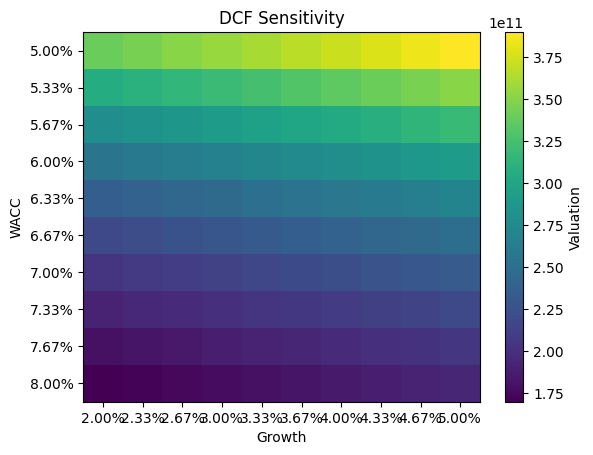

In [11]:
plt.imshow(df, aspect='auto')
plt.colorbar(label='Valuation')
plt.xticks(range(len(growth_values)), [f'{g:.2%}' for g in growth_values])
plt.yticks(range(len(wacc_values)), [f'{w:.2%}' for w in wacc_values])
plt.xlabel('Growth')
plt.ylabel('WACC')
plt.title('DCF Sensitivity')
plt.show()

## 9. Reflection
- Compare DCF vs market
- Check assumptions
- Observe sensitivity